Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'model__estimator__alpha': 2.0, 'model__max_samples': 0.6, 'model__n_estimators': 10}
✅ Accuracy : 82.26%
✅ Precision: 84.94%
✅ Recall   : 82.26%
✅ F1 Score : 83.05%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\3449147823.py:160: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


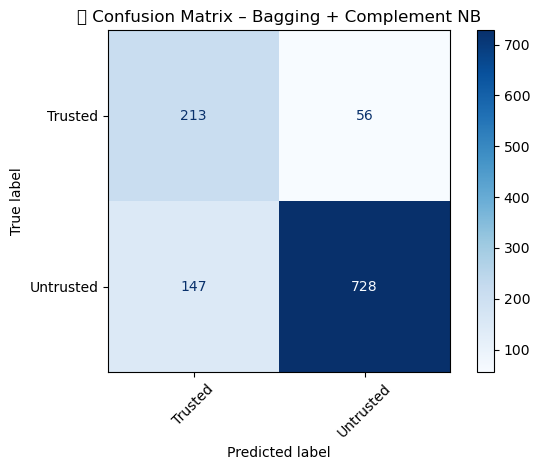

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\3449147823.py:181: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.grid(); plt.legend(); plt.tight_layout(); plt.show()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


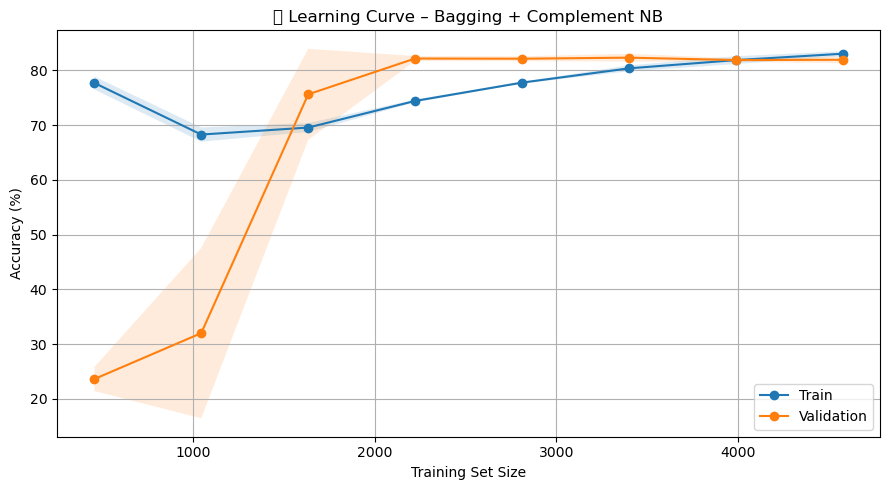

In [ ]:
# Naive bayes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler          # ← keeps data ≥ 0
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     learning_curve, KFold)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             ConfusionMatrixDisplay)

df = pd.read_csv("Insta_output_binary_classification_2classes.csv",
                 encoding="latin1")
df.columns = df.columns.str.strip()
df = df[df["binary_label"].isin(["Trusted", "Untrusted"])]
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df["bio_text"] = df["biography"].fillna("")
df["all_hashtags"] = (df["post_hashtags"].fillna("") + " " +
                      df["bio_hashtags"].fillna("")).str.replace(
                          r'[\[\]\"]', " ", regex=True)
df["text_features"] = df["bio_text"] + " " + df["all_hashtags"]

# cast numeric-like columns to real numbers
for col in ["followers", "following", "posts_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["following"] = df["following"].replace(0, 1)       # avoid ÷0

# robust TRUE/FALSE → 1/0
def bool_to_int(series):
    truthy = {"1", "true", "yes", "y", "t"}
    return (series.fillna("0")
                  .astype(str)
                  .str.strip()
                  .str.lower()
                  .isin(truthy)
                  .astype(int))

df["is_verified"]             = bool_to_int(df["is_verified"])
df["is_professional_account"] = bool_to_int(df["is_professional_account"])
df["is_business_account"]     = bool_to_int(df["is_business_account"])

# follower ratio
df["follower_ratio"] = df["followers"] / df["following"]

# profile completeness
comp_cols = ["biography", "profile_image_link",
             "business_email", "external_url"]
df["profile_completeness"] = df[comp_cols].notna().mean(axis=1)

# activity score
df["activity_score"] = df["posts_count"]

# VAT flag (placeholder until scraper added)
df["vat_valid"] = 0

# other validation  – combine several quick checks
def presence(col):
    return (~df[col].isna() & df[col].astype(str).str.len().gt(0)).astype(int)
other_checks = [
    df["is_verified"],
    df["is_professional_account"],
    presence("external_url"),
    presence("business_address_json"),
    presence("fbid")
]
df["other_validation"] = np.vstack(other_checks).sum(axis=0)

BUSINESS_W     = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
NON_BUSINESS_W = np.array([0.30, 0.25, 0.25, 0.00, 0.20])

base = df[["follower_ratio", "profile_completeness",
           "activity_score", "vat_valid", "other_validation"]].values
weights = np.where(df["is_business_account"].values.reshape(-1, 1),
                   BUSINESS_W, NON_BUSINESS_W)

df["trust_score_formula"] = (base * weights).sum(axis=1)


text_feat     = "text_features"
numeric_feats = ["follower_ratio", "profile_completeness",
                 "activity_score", "vat_valid",
                 "other_validation", "trust_score_formula"]

X = df[[text_feat] + numeric_feats]
y = df["binary_label"].values

preprocessor = ColumnTransformer([
        ("txt", TfidfVectorizer(stop_words="english",
                                max_features=2000), text_feat),
        ("num", Pipeline([("sc", MinMaxScaler())]), numeric_feats)
    ])

pipe = Pipeline([
        ("prep", preprocessor),
        ("model", BaggingClassifier(estimator=ComplementNB(),
                                    random_state=42))
    ])

param_grid = {
    "model__n_estimators":        [10, 20, 30],
    "model__max_samples":         [0.6, 0.8, 1.0],
    "model__estimator__alpha":    [0.5, 1.0, 2.0]
}

X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42)

grid = GridSearchCV(pipe, param_grid, cv=5,
                    scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
print("Best params:", grid.best_params_)

joblib.dump(best, "naive_bayes.pkl")

pred = best.predict(X_te)
print(f"✅ Accuracy : {accuracy_score(y_te, pred)*100:.2f}%")
print(f"✅ Precision: {precision_score(y_te, pred, average='weighted')*100:.2f}%")
print(f"✅ Recall   : {recall_score(y_te, pred, average='weighted')*100:.2f}%")
print(f"✅ F1 Score : {f1_score(y_te, pred, average='weighted')*100:.2f}%")

ConfusionMatrixDisplay.from_predictions(
    y_te, pred, display_labels=np.unique(y),
    cmap="Blues", xticks_rotation=45)
plt.title("📊 Confusion Matrix – Bagging + Complement NB")
plt.tight_layout(); plt.show()

cv = KFold(n_splits=5, shuffle=True, random_state=42)
sizes, tr, val = learning_curve(
        best, X, y, cv=cv, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.plot(sizes, tr.mean(axis=1)*100, "o-", label="Train")
plt.plot(sizes, val.mean(axis=1)*100, "o-", label="Validation")
plt.fill_between(sizes,
                 (tr.mean(axis=1)-tr.std(axis=1))*100,
                 (tr.mean(axis=1)+tr.std(axis=1))*100, alpha=.15)
plt.fill_between(sizes,
                 (val.mean(axis=1)-val.std(axis=1))*100,
                 (val.mean(axis=1)+val.std(axis=1))*100, alpha=.15)
plt.title("📈 Learning Curve – Bagging + Complement NB")
plt.xlabel("Training Set Size"); plt.ylabel("Accuracy (%)")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


✅ Accuracy : 80.94%
✅ Precision: 86.09%
✅ Recall   : 80.94%
✅ F1 Score : 82.13%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\3736853283.py:94: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


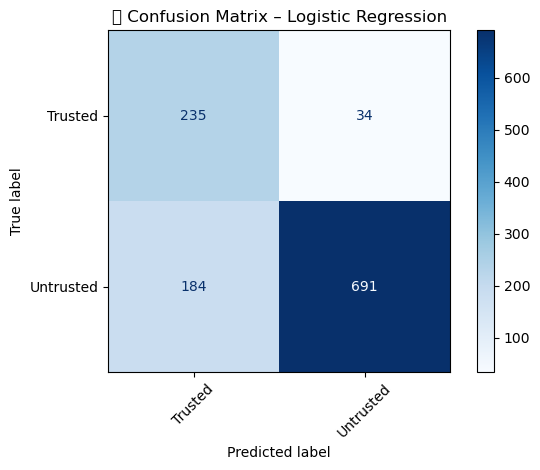

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\3736853283.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.grid(); plt.legend(); plt.tight_layout(); plt.show()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


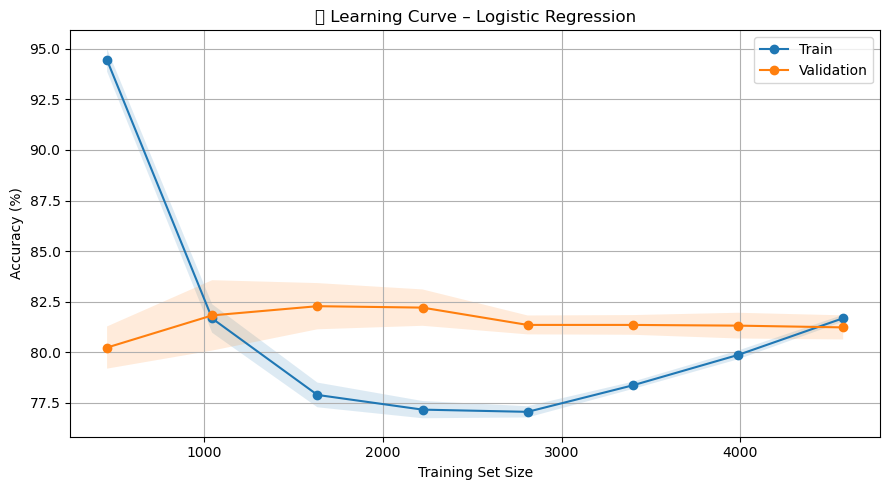

In [ ]:
# Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("Insta_output_binary_classification_2classes.csv", encoding="latin1")
df.columns = df.columns.str.strip()
df = df[df["binary_label"].isin(["Trusted", "Untrusted"])]
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Text features
df["bio_text"] = df["biography"].fillna("")
df["all_hashtags"] = (df["post_hashtags"].fillna("") + " " + df["bio_hashtags"].fillna("")).str.replace(r'[\[\]\"]', " ", regex=True)
df["text_features"] = df["bio_text"] + " " + df["all_hashtags"]

# Numeric features
for col in ["followers", "following", "posts_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
df["following"] = df["following"].replace(0, 1)

def bool_to_int(series):
    truthy = {"1", "true", "yes", "y", "t"}
    return (series.fillna("0").astype(str).str.strip().str.lower().isin(truthy).astype(int))

df["is_verified"] = bool_to_int(df["is_verified"])
df["is_professional_account"] = bool_to_int(df["is_professional_account"])
df["is_business_account"] = bool_to_int(df["is_business_account"])

df["follower_ratio"] = df["followers"] / df["following"]
df["profile_completeness"] = df[["biography", "profile_image_link", "business_email", "external_url"]].notna().mean(axis=1)
df["activity_score"] = df["posts_count"]
df["vat_valid"] = 0

def presence(col):
    return (~df[col].isna() & df[col].astype(str).str.len().gt(0)).astype(int)

other_checks = [
    df["is_verified"],
    df["is_professional_account"],
    presence("external_url"),
    presence("business_address_json"),
    presence("fbid")
]
df["other_validation"] = np.vstack(other_checks).sum(axis=0)

# Trust formula
BUSINESS_W = np.array([0.20, 0.20, 0.20, 0.20, 0.20])
NON_BUSINESS_W = np.array([0.30, 0.25, 0.25, 0.00, 0.20])
base = df[["follower_ratio", "profile_completeness", "activity_score", "vat_valid", "other_validation"]].values
weights = np.where(df["is_business_account"].values.reshape(-1, 1), BUSINESS_W, NON_BUSINESS_W)
df["trust_score_formula"] = (base * weights).sum(axis=1)

# Define features
text_feat = "text_features"
numeric_feats = ["follower_ratio", "profile_completeness", "activity_score", "vat_valid", "other_validation", "trust_score_formula"]
X = df[[text_feat] + numeric_feats]
y = df["binary_label"].values

# Pipeline
preprocessor = ColumnTransformer([
    ("txt", TfidfVectorizer(stop_words="english", max_features=1000), text_feat),
    ("num", Pipeline([("sc", MinMaxScaler())]), numeric_feats)
])

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear"))
])

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
pipe.fit(X_tr, y_tr)

# Save model
joblib.dump(pipe, "logistic_model.pkl")

# Evaluate
pred = pipe.predict(X_te)
print(f"✅ Accuracy : {accuracy_score(y_te, pred)*100:.2f}%")
print(f"✅ Precision: {precision_score(y_te, pred, average='weighted')*100:.2f}%")
print(f"✅ Recall   : {recall_score(y_te, pred, average='weighted')*100:.2f}%")
print(f"✅ F1 Score : {f1_score(y_te, pred, average='weighted')*100:.2f}%")

ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=np.unique(y), cmap="Blues", xticks_rotation=45)
plt.title("📊 Confusion Matrix – Logistic Regression")
plt.tight_layout(); plt.show()

# Learning Curve
cv = KFold(n_splits=5, shuffle=True, random_state=42)
sizes, tr, val = learning_curve(pipe, X, y, cv=cv, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.plot(sizes, tr.mean(axis=1)*100, "o-", label="Train")
plt.plot(sizes, val.mean(axis=1)*100, "o-", label="Validation")
plt.fill_between(sizes, (tr.mean(axis=1)-tr.std(axis=1))*100, (tr.mean(axis=1)+tr.std(axis=1))*100, alpha=.15)
plt.fill_between(sizes, (val.mean(axis=1)-val.std(axis=1))*100, (val.mean(axis=1)+val.std(axis=1))*100, alpha=.15)
plt.title("📈 Learning Curve – Logistic Regression")
plt.xlabel("Training Set Size"); plt.ylabel("Accuracy (%)")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


✅ Accuracy : 81.12%
✅ Precision: 86.25%
✅ Recall   : 81.12%
✅ F1 Score : 82.29%


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\156346397.py:96: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


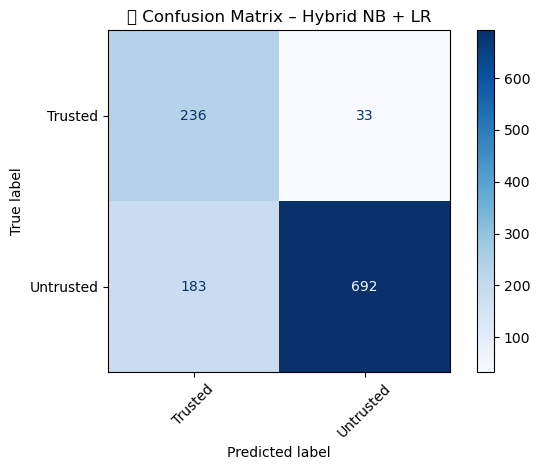

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11012\156346397.py:119: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


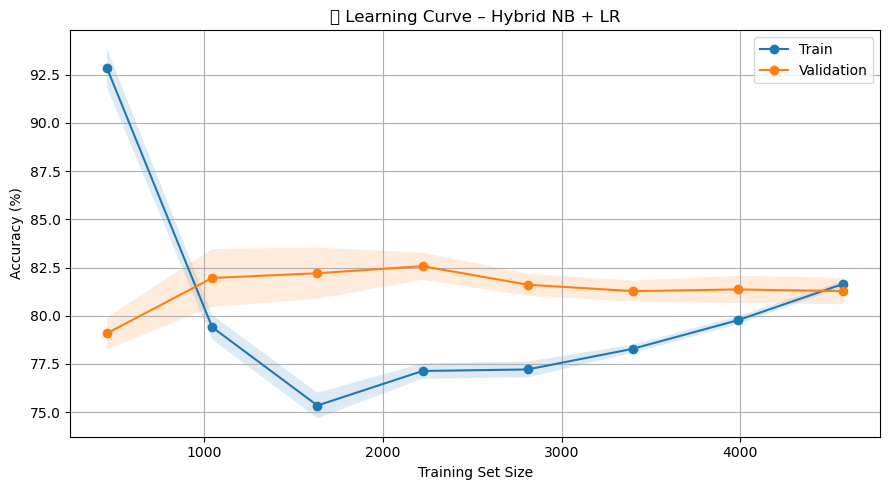

In [ ]:
#hybrid LR and NB

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv("Insta_output_binary_classification_2classes.csv", encoding="latin1")
df.columns = df.columns.str.strip()
df = df[df["binary_label"].isin(["Trusted", "Untrusted"])]
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Feature engineering
df["bio_text"] = df["biography"].fillna("")
df["all_hashtags"] = (df["post_hashtags"].fillna("") + " " + df["bio_hashtags"].fillna("")).str.replace(r'[\[\]\"]', " ", regex=True)
df["text_features"] = df["bio_text"] + " " + df["all_hashtags"]

for col in ["followers", "following", "posts_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
df["following"] = df["following"].replace(0, 1)

def bool_to_int(series):
    truthy = {"1", "true", "yes", "y", "t"}
    return (series.fillna("0").astype(str).str.strip().str.lower().isin(truthy).astype(int))

df["is_verified"] = bool_to_int(df["is_verified"])
df["is_professional_account"] = bool_to_int(df["is_professional_account"])
df["is_business_account"] = bool_to_int(df["is_business_account"])

df["follower_ratio"] = df["followers"] / df["following"]
df["profile_completeness"] = df[["biography", "profile_image_link", "business_email", "external_url"]].notna().mean(axis=1)
df["activity_score"] = df["posts_count"]
df["vat_valid"] = 0

def presence(col):
    return (~df[col].isna() & df[col].astype(str).str.len().gt(0)).astype(int)

df["other_validation"] = (
    df["is_verified"]
    + df["is_professional_account"]
    + presence("external_url")
    + presence("business_address_json")
    + presence("fbid")
)

# Trust score formula
BUSINESS_W = np.array([0.20] * 5)
NON_BUSINESS_W = np.array([0.30, 0.25, 0.25, 0.00, 0.20])
base = df[["follower_ratio", "profile_completeness", "activity_score", "vat_valid", "other_validation"]].values
weights = np.where(df["is_business_account"].values.reshape(-1, 1), BUSINESS_W, NON_BUSINESS_W)
df["trust_score_formula"] = (base * weights).sum(axis=1)

# Features
text_feat = "text_features"
numeric_feats = ["follower_ratio", "profile_completeness", "activity_score", "vat_valid", "other_validation", "trust_score_formula"]
X = df[[text_feat] + numeric_feats]
y = df["binary_label"].values

# Preprocessing and pipeline
preprocessor = ColumnTransformer([
    ("txt", TfidfVectorizer(stop_words="english", max_features=1000), text_feat),
    ("num", Pipeline([("sc", MinMaxScaler())]), numeric_feats)
])

nb = ComplementNB()
lr = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
voter = VotingClassifier(estimators=[("nb", nb), ("lr", lr)], voting="soft", weights=[1, 2])

pipe = Pipeline([("prep", preprocessor), ("model", voter)])

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipe.fit(X_tr, y_tr)

# Save model
joblib.dump(pipe, "hybrid_nb_lr_model.pkl")

# Evaluate
pred = pipe.predict(X_te)
print(f"✅ Accuracy : {accuracy_score(y_te, pred) * 100:.2f}%")
print(f"✅ Precision: {precision_score(y_te, pred, average='weighted') * 100:.2f}%")
print(f"✅ Recall   : {recall_score(y_te, pred, average='weighted') * 100:.2f}%")
print(f"✅ F1 Score : {f1_score(y_te, pred, average='weighted') * 100:.2f}%")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_te, pred, display_labels=np.unique(y), cmap="Blues", xticks_rotation=45)
plt.title("📊 Confusion Matrix – Hybrid NB + LR")
plt.tight_layout()
plt.show()

# Learning Curve
cv = KFold(n_splits=5, shuffle=True, random_state=42)
sizes, train_scores, val_scores = learning_curve(pipe, X, y, cv=cv, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.plot(sizes, train_scores.mean(axis=1) * 100, "o-", label="Train")
plt.plot(sizes, val_scores.mean(axis=1) * 100, "o-", label="Validation")
plt.fill_between(sizes,
                 (train_scores.mean(axis=1) - train_scores.std(axis=1)) * 100,
                 (train_scores.mean(axis=1) + train_scores.std(axis=1)) * 100,
                 alpha=0.15)
plt.fill_between(sizes,
                 (val_scores.mean(axis=1) - val_scores.std(axis=1)) * 100,
                 (val_scores.mean(axis=1) + val_scores.std(axis=1)) * 100,
                 alpha=0.15)
plt.title("📈 Learning Curve – Hybrid NB + LR")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
